<a href="https://colab.research.google.com/github/benhamad-mhemed/pfe-master/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie 2 : Traitement et Apprentissage Machine Learning

## 1- Importation des Bibliothèques

In [1]:
# Importation des bibliothèques
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Connexion google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2- Chargement du dataset

In [2]:
df = pd.read_excel("/content/drive/MyDrive/Master/Scolarite/resultats/df_1A.xlsx")

## 3- Machine Learning

### Séparer la variable cible (y) et les variables explicatives (X)

In [3]:
y = df["Orientation"]      # variable à prédire
X = df.drop(columns=["Orientation"])

### Encoder la variable cible

In [4]:
# (machine learning utilise des nombres)
le = LabelEncoder()
y = le.fit_transform(y)

### Séparer train et test

In [5]:
# 80% entrainement
# 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### === Évaluation des modèles de classification pour l'orientation des élèves ===

### Random Forest

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,   # nombre d'arbres
    max_depth=10,       # profondeur maximale
    random_state=42
)

# entrainement
rf_model.fit(X_train, y_train)

# prédiction
y_pred = rf_model.predict(X_test)

# évaluation
print("===== RANDOM FOREST =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== RANDOM FOREST =====
Accuracy : 0.6133004926108374
              precision    recall  f1-score   support

           0       0.50      0.05      0.10        37
           1       0.67      0.56      0.61       100
           2       0.51      0.34      0.41        83
           3       0.51      0.82      0.63       125
           4       0.95      1.00      0.98        61

    accuracy                           0.61       406
   macro avg       0.63      0.55      0.54       406
weighted avg       0.62      0.61      0.58       406



### Logistic Regression

In [7]:
# normaliser les données
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=5000
)

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== LOGISTIC REGRESSION =====
Accuracy : 0.6231527093596059
              precision    recall  f1-score   support

           0       0.38      0.14      0.20        37
           1       0.69      0.58      0.63       100
           2       0.49      0.42      0.45        83
           3       0.53      0.75      0.62       125
           4       0.98      1.00      0.99        61

    accuracy                           0.62       406
   macro avg       0.62      0.58      0.58       406
weighted avg       0.62      0.62      0.61       406



### Gradient Boosting

In [8]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("===== GRADIENT BOOSTING =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== GRADIENT BOOSTING =====
Accuracy : 0.6280788177339901
              precision    recall  f1-score   support

           0       0.38      0.16      0.23        37
           1       0.70      0.57      0.63       100
           2       0.47      0.43      0.45        83
           3       0.56      0.76      0.64       125
           4       0.98      1.00      0.99        61

    accuracy                           0.63       406
   macro avg       0.62      0.59      0.59       406
weighted avg       0.62      0.63      0.61       406



### SVM

In [9]:
svm_model = SVC(
    kernel="rbf"
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("===== SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== SVM =====
Accuracy : 0.6206896551724138
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.69      0.57      0.62       100
           2       0.60      0.30      0.40        83
           3       0.51      0.90      0.66       125
           4       0.93      0.93      0.93        61

    accuracy                           0.62       406
   macro avg       0.55      0.54      0.52       406
weighted avg       0.59      0.62      0.58       406



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Decision Tree

In [10]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("===== DECISION TREE =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== DECISION TREE =====
Accuracy : 0.5738916256157636
              precision    recall  f1-score   support

           0       0.35      0.22      0.27        37
           1       0.62      0.55      0.58       100
           2       0.37      0.34      0.35        83
           3       0.52      0.65      0.57       125
           4       0.98      1.00      0.99        61

    accuracy                           0.57       406
   macro avg       0.57      0.55      0.55       406
weighted avg       0.57      0.57      0.57       406



### KNN

In [11]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print("===== KNN =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== KNN =====
Accuracy : 0.5640394088669951
              precision    recall  f1-score   support

           0       0.44      0.38      0.41        37
           1       0.59      0.61      0.60       100
           2       0.43      0.40      0.41        83
           3       0.51      0.58      0.54       125
           4       0.92      0.80      0.86        61

    accuracy                           0.56       406
   macro avg       0.58      0.55      0.56       406
weighted avg       0.57      0.56      0.57       406



### Naive Bayes

In [12]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

print("===== NAIVE BAYES =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

===== NAIVE BAYES =====
Accuracy : 0.5640394088669951
              precision    recall  f1-score   support

           0       0.30      0.35      0.33        37
           1       0.55      0.66      0.60       100
           2       0.37      0.30      0.33        83
           3       0.59      0.51      0.55       125
           4       0.90      1.00      0.95        61

    accuracy                           0.56       406
   macro avg       0.54      0.56      0.55       406
weighted avg       0.56      0.56      0.56       406



### Nombre élève par orientation

In [13]:
df["Orientation"].value_counts()

,count
Orientation,
4,628
2,482
3,423
5,303
1,193


### Faire une prédiction

In [14]:
# =====================================
# PRÉDICTION D'UN NOUVEL ÉLÈVE
# =====================================

# Notes brutes du nouvel élève
arabe = 14
francais = 12
anglais = 13
math = 15
sc_physique = 17
svt = 10
techno = 18
info = 18
hist_geo = 11


# Créer le DataFrame pour prédiction
nouvel_eleve = pd.DataFrame([[
    0,          # Genre
    20,         # Age
    0,          # Type_Handicap
    1,          # Etat_Famille
    1,          # Type_Residence
    2,          # Jours_Abs
    3,          # Jours_Sanc
    0,          # Annee_Redoublement
    arabe,      # Arabe
    francais,   # Français
    anglais,    # Anglais
    math,       # Math
    sc_physique,# Sc_Physique
    svt,        # SVT
    techno,     # Techno
    info,       # Info
    hist_geo,   # Hist_Geo
    14,         # Moy_Annuel
    1           # Decision
]], columns=X.columns)
# Dictionnaire de correspondance
sections = {
    1: "section lettre",
    2: "section science",
    3: "section technologie informatique",
    4: "section economie et service",
    5: "non orienté"
}
# Prédiction
# prediction = model.predict(nouvel_eleve) # changer model par le model choisi
prediction = lr_model.predict(nouvel_eleve)
# Décoder le LabelEncoder
pred_val = le.inverse_transform(prediction)[0]

# Convertir en section lisible
section_orientee = sections.get(pred_val, "section inconnue")

print("Orientation prédite :", pred_val)
print("Section :", section_orientee)

Orientation prédite : 2
Section : section science


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Comparaison entre les performances des modèles

### définir les modèles

In [15]:
# =========================================
# DÉFINITION DES MODÈLES
# =========================================
models = {

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(kernel="rbf")

}

In [16]:
# =========================================
# COMPARAISON DES MODÈLES
# =========================================
results = {}

for name, model in models.items():

    # entraîner modèle
    model.fit(X_train, y_train)

    # prédire
    y_pred = model.predict(X_test)

    # calcul précision
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

# créer tableau
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

# trier
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy
3  Logistic Regression  0.620690
6                  SVM  0.620690
2    Gradient Boosting  0.618227
0        Random Forest  0.608374
4                  KNN  0.564039
5          Naive Bayes  0.564039
1        Decision Tree  0.539409


### Graphique

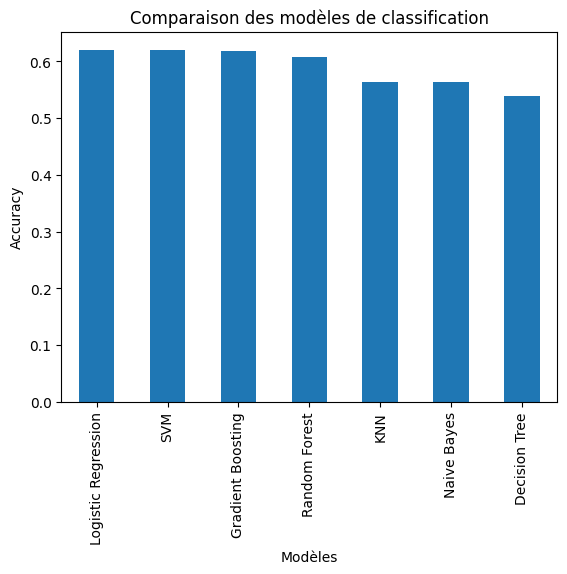

In [17]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Comparaison des modèles de classification")
plt.ylabel("Accuracy")
plt.xlabel("Modèles")

plt.show()

### Importance des matières (Feature Importance)

In [18]:
# =========================================
# IMPORTANCE DES VARIABLES
# =========================================
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

Moy_Ann        0.198480
Decision       0.132734
Math           0.097057
Sc_Phys        0.086877
SVT            0.083556
Arabe          0.066982
Français       0.060247
Info           0.059148
Hist_Geo       0.055265
Techno         0.052976
Anglais        0.050552
Genre          0.016531
Age            0.014356
Nbr_Ann_Red    0.009114
Jours_Abs      0.004997
Etat_Fam       0.004071
Type_Res       0.003143
Type_Hand      0.002257
Jours_Sanc     0.001657
dtype: float64


### Graphique

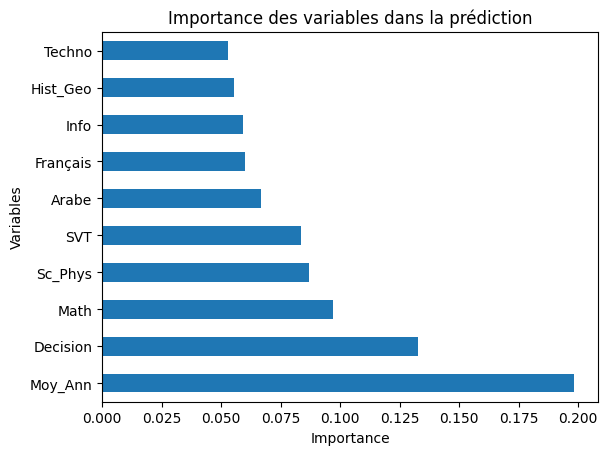

In [19]:
importance.head(10).plot(kind="barh")

plt.title("Importance des variables dans la prédiction")
plt.xlabel("Importance")
plt.ylabel("Variables")

plt.show()

### Matrice de confusion

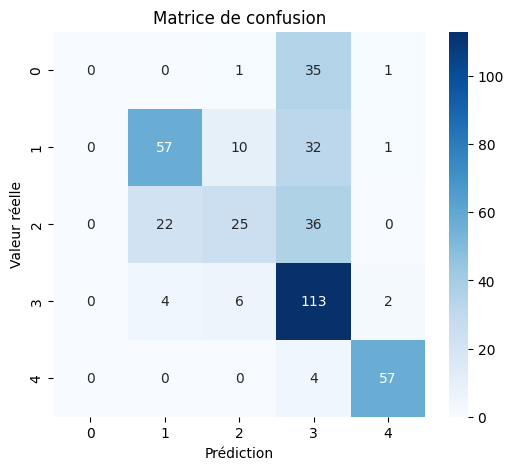

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

### Comparaison entre la prédiction pour un élève entre modèles

In [21]:
print("Random Forest :", rf_model.predict(nouvel_eleve))
print("Decision Tree :", dt_model.predict(nouvel_eleve))
print("SVM :", svm_model.predict(nouvel_eleve))
print("Logistic Regression :", lr_model.predict(nouvel_eleve))
print("KNN :", knn_model.predict(nouvel_eleve))
print("Naive Bayes :", nb_model.predict(nouvel_eleve))
print("Gradient Boosting :", gb_model.predict(nouvel_eleve))


Random Forest : [2]
Decision Tree : [2]
SVM : [2]
Logistic Regression : [1]
KNN : [1]
Naive Bayes : [3]
Gradient Boosting : [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
